# Transformer encoders and a fused multimodal transformer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/experimental/transformer_encoders.ipynb)

> **Experimental.** Transformer encoders were not used for the results in the paper. This notebook
> compares them with the standard MLP encoders on identical inputs and reports whatever comes out; it
> does not assume that attention helps.

UniVI can encode a modality with a transformer over **tokens**, where each token is one of the cell's
most prominent features (a highly expressed gene, an accessible peak) carrying its value, its rank,
and a learned embedding of *which* feature it is. It can also encode all modalities jointly with one
**fused transformer** over the concatenated tokens, so that gene tokens and peak tokens attend to each
other before the latent posterior is formed.

On 10x Multiome PBMCs this notebook:

1. builds token-friendly inputs (z-scored RNA, TF-IDF-weighted peaks);
2. trains five models on the same cells and features: MLP (paper objective, `v1`), per-modality
   transformers (`v1`), per-modality transformers whose ATAC tokens also know their genomic position
   (`v1`), MLP (`v2`), and MLP experts plus a fused transformer (`v2`);
3. compares alignment, label transfer, ATAC → RNA prediction, fused-embedding quality and training time;
4. opens up the fused transformer: a single cell's attention map, how sharp attention is in each layer,
   how much of it crosses modalities (overall and per cell type), which tokens the pooled embedding
   depends on (attention rollout) and whether that adds anything to simply being a token, attention
   sinks, pair-specific gene–peak links, and whether a gene token attends more to **cis** peaks (near
   its TSS) than to other peaks in the same cell.

The last test is a falsifiable check: attention weights are not explanations, but if the fused encoder
had learned nothing about genomic proximity, cis peaks would receive no more of a gene's attention than
other peaks.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.2" "pandas==2.2.3"

In [2]:
import time
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from IPython.display import display
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

import univi
import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.config import TokenizerConfig, TransformerConfig
from univi.evaluation import (cross_modal_predict, encode_adata, encode_fused_adata_pair, evaluate_alignment,
                              pearson_corr_per_feature)
from univi.interpretability import fused_encode_with_meta_and_attn, top_cross_modal_feature_pairs_from_attn
from univi.preprocessing import RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import load_reference, make_loader, save_reference

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
dense = lambda x: x.toarray() if sp.issparse(x) else np.asarray(x)
print(f"UniVI {univi.__version__} on {device}")

UniVI 1.2.0 on cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 300
BATCH_SIZE = 256
N_HVG = 2000
N_PEAKS = 20000            # most frequently open peaks in training cells
ATAC_RECON_WEIGHT = 0.2    # balances the ATAC reconstruction sum against RNA's; tune if needed
N_TOKENS_RNA = 128         # genes per cell given to the transformer (the cell's highest z-scores)
N_TOKENS_ATAC = 128        # peaks per cell (the cell's highest TF-IDF values)
D_TOKEN = 64               # token embedding size before the transformer
TRANSFORMER = dict(d_model=128, num_heads=4, num_layers=2, dim_feedforward=256, dropout=0.1, attn_dropout=0.1)
CIS_WINDOW_BP = 100_000    # gene-peak pairs closer than this (same chromosome) count as cis
N_PERMUTATIONS = 200       # peak-coordinate shuffles for the cis-attention null
N_UNTRAINED_CONTROLS = 5   # untrained copies of the fused model, as a reference for the cis test
MAX_ATTENTION_CELLS = 2000
RUN_POSITION_MODEL = True  # also train the transformer whose ATAC tokens carry genomic coordinates
N_DE_GENES = 50            # marker genes per cell type for the attention-rollout test
TOP_PAIRS_PER_CELL = 20    # strongest (centered) gene -> peak pairs taken from each cell
MIN_COOCCURRENCE = 20      # a pair must have both tokens present in at least this many cells
OUTPUT_DIR = "univi_outputs"

## 1. Data and token-friendly inputs

A top-k tokenizer keeps each cell's **largest** values. For RNA we z-score log-normalized expression,
so the kept genes are those most above their average level in that cell. For ATAC, binarized peaks
would tie (every open peak equals 1), so we use Signac-style TF-IDF, `log1p(TF × IDF × 1e4)` with the
IDF fit on training cells: the kept peaks are the cell's open peaks that are rarest across cells,
which is where cell identity lives. All four models receive exactly these inputs.

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
splits = split_by_label(rna.obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=0)
print({k: len(v) for k, v in splits.items()})

rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[splits["train"]])
train_counts = sp.csr_matrix(atac[splits["train"]].layers["counts"])
freq = np.asarray((train_counts > 0).mean(axis=0)).ravel()
keep = np.argsort(-freq, kind="stable")[: min(N_PEAKS, int((freq > 0).sum()))]
df = np.asarray((train_counts[:, keep] > 0).sum(axis=0)).ravel()
idf = np.log1p(train_counts.shape[0] / (1.0 + df)).astype(np.float32)


def tfidf(adata_counts):
    x = sp.csr_matrix(adata_counts.layers["counts"][:, keep], dtype=np.float32)
    x.data = np.ones_like(x.data)                                  # binarize, then TF-IDF
    tf = sp.diags(1.0 / np.maximum(np.asarray(x.sum(axis=1)).ravel(), 1.0)) @ x
    out = sp.csr_matrix(tf.multiply(idf[None, :]))
    out.data = np.log1p(out.data * 1e4).astype(np.float32)
    return ad.AnnData(out, obs=adata_counts.obs.copy(), var=atac.var.iloc[keep].copy())


parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": tfidf(atac[i])} for k, i in splits.items()}
train, val, test = parts["train"], parts["val"], parts["test"]
print("RNA", train["rna"].shape, "| ATAC", train["atac"].shape)

{'train': 7698, 'val': 956, 'test': 977}
RNA (7698, 2000) | ATAC (7698, 20000)


## 2. Four models on the same inputs

A top-k token says "this feature has this value and this rank in this cell". Without an identity
embedding the transformer would not know *which* gene or peak a token is, so the tokenizers below switch
on a learned **feature-ID embedding** (`use_feature_embedding=True`). ATAC tokens of the position model
additionally get a **genomic coordinate embedding** (`use_coord_embedding=True`: a chromosome embedding
plus multi-scale sinusoidal features of the peak midpoint, from 1 kb to 100 Mb), and its transformer adds
a learned attention bias for binned genomic distance between peak tokens (`use_relpos_bias=True`; peaks
on different chromosomes share the farthest bin). These options work since UniVI 1.2.0.

The fused transformer is only trained by the `v2` objective (in `v1` its posterior never enters the
reconstruction loss), so an MLP model with `v2` is included to separate the effect of the fused encoder
from the effect of the objective. `recon_normalize_by_dim=False` keeps `v2` reconstruction sums on the
same scale as `v1`, so the same `beta` and `gamma` are used throughout.

**A note on fused encoders.** When a fused encoder produces the posterior, the per-modality encoders take
no part in reconstruction; the alignment term (each modality's posterior mean pulled toward the fused one)
is their only training signal, and with the paper's schedule it is annealed in from epoch 75. Before UniVI
1.2.0 the zero-weighted term stayed in the loss, the encoders received zero gradients, and Adam's weight
decay drove their weights to zero before alignment began: in a run of this notebook with UniVI 1.1 every
per-modality embedding of the fused model was the same point (FOSCTTM 0.000 from tied distances, Recall@10
0.01, label transfer at chance). UniVI 1.2.0 leaves a zero-weighted term out of the loss, so all five
models here use the paper's schedule. The check after training reports any per-modality encoder whose
output barely varies across cells.

In [5]:
atac_chroms = sorted(set(train["atac"].var["chrom"].astype(str))) if "chrom" in train["atac"].var else []


def tokenizer(n_features, n_tokens, position=False):
    return TokenizerConfig(mode="topk_channels", n_tokens=n_tokens, channels=("value", "rank"),
                           n_features=int(n_features), use_feature_embedding=True, feature_emb_dim=D_TOKEN,
                           use_coord_embedding=position, n_chroms=len(atac_chroms) if position else None)


def modalities(encoder):
    n_rna, n_atac = train["rna"].n_vars, train["atac"].n_vars
    position = encoder == "transformer+position"
    if encoder == "mlp":                     # MLP experts; the tokenizers are used only by a fused encoder
        kw_rna, kw_atac = dict(tokenizer=tokenizer(n_rna, N_TOKENS_RNA)), dict(tokenizer=tokenizer(n_atac, N_TOKENS_ATAC))
    else:
        tcfg_atac = TransformerConfig(**TRANSFORMER, use_relpos_bias=position, relpos_num_bins=32, relpos_max_dist=1e6)
        kw_rna = dict(encoder_type="transformer", transformer=TransformerConfig(**TRANSFORMER),
                      tokenizer=tokenizer(n_rna, N_TOKENS_RNA))
        kw_atac = dict(encoder_type="transformer", transformer=tcfg_atac,
                       tokenizer=tokenizer(n_atac, N_TOKENS_ATAC, position=position))
    return [ModalityConfig("rna", n_rna, [512, 256, 128], [128, 256, 512], likelihood="gaussian", **kw_rna),
            ModalityConfig("atac", n_atac, [512, 256, 128], [128, 256, 512], likelihood="gaussian",
                           recon_weight=ATAC_RECON_WEIGHT, **kw_atac)]


def attach_peak_coordinates(model):
    """Coordinates are data, not weights: attach them after building (or loading) a position model."""
    v = getattr(model.encoders["atac"], "vec2tok", None)
    if v is None or not v.use_coord_emb:
        return
    var = train["atac"].var
    chrom = np.array(var["chrom"].astype(str).map({c: i for i, c in enumerate(atac_chroms)}), dtype=np.int64)
    v.set_feature_coords(torch.from_numpy(chrom), torch.from_numpy(np.array(var["chromStart"], dtype=np.float32)),
                         torch.from_numpy(np.array(var["chromEnd"], dtype=np.float32)))


common = dict(latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
              kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110)
specs = {
    "MLP (v1)": (UniVIConfig(modalities=modalities("mlp"), **common), dict(loss_mode="v1", v1_recon="avg")),
    "transformer (v1)": (UniVIConfig(modalities=modalities("transformer"), **common),
                         dict(loss_mode="v1", v1_recon="avg")),
    "transformer + position (v1)": (UniVIConfig(modalities=modalities("transformer+position"), **common),
                                    dict(loss_mode="v1", v1_recon="avg")),
    "MLP (v2)": (UniVIConfig(modalities=modalities("mlp"), **common),
                 dict(loss_mode="v2", recon_normalize_by_dim=False)),
    "fused transformer (v2)": (UniVIConfig(modalities=modalities("mlp"), fused_encoder_type="multimodal_transformer",
                                           fused_transformer=TransformerConfig(**TRANSFORMER), **common),
                               dict(loss_mode="v2", recon_normalize_by_dim=False)),
}

if not RUN_POSITION_MODEL or not atac_chroms:
    specs.pop("transformer + position (v1)")
models, histories, minutes = {}, {}, {}
for name, (cfg, kwargs) in specs.items():
    set_seed(0)
    model = UniVIMultiModalVAE(cfg, normalize_v1_terms=True, **kwargs)
    attach_peak_coordinates(model)
    n_params = sum(p.numel() for p in model.parameters())
    trainer = UniVITrainer(
        model, make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
        make_loader(val, batch_size=512),
        TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device,
                       early_stopping=True, patience=50, best_epoch_warmup=110, log_every=100, grad_clip=5.0))
    started = time.time()
    histories[name] = trainer.fit()
    minutes[name] = (time.time() - started) / 60
    models[name] = model
    print(f"{name}: {n_params / 1e6:.1f}M parameters, best epoch {trainer.best_epoch}, {minutes[name]:.1f} min")

fused_tok = models["fused transformer (v2)"].fused_encoder.vec2tok
assert all(fused_tok[m].id_emb is not None for m in fused_tok), "feature-ID embeddings missing in fused encoder"

spread = pd.DataFrame({name: {m: float(encode_adata(model, val[m], modality=m, device=device,
                                                     latent="modality_mean").std(0).mean()) for m in ("rna", "atac")}
                       for name, model in models.items()}).T
spread.columns = [f"{m} embedding s.d. across cells" for m in spread.columns]
display(spread.round(4))
collapsed = spread[(spread < 1e-3).any(axis=1)].index.tolist()
if collapsed:
    print("WARNING: per-modality encoders with (near-)constant output:", collapsed,
          "- their alignment, label-transfer and cross-modal metrics are not meaningful.")

[2026-09-22 22:15:07,893] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-22 22:15:07,894] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-22 22:15:07,894] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-22 22:15:07,894] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-22 22:15:07,894] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-22 22:15:07,895] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-22 22:15:07,895] [UniVITrainer] [INFO]   log_every: 100
[2026-09-22 22:15:07,896] [UniVITrainer] [INFO]   grad_clip: 5.0
[2026-09-22 22:15:07,896] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-22 22:15:07,896] [UniVITrainer] [INFO]   seed: 0
[2026-09-22 22:15:07,897] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-22 22:15:07,897] [UniVITrainer] [INFO]   patience: 50
[2026-09-22 22:15:07,897] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-22 22:15:07,898] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-22 22:15:10,131] [Uni

MLP (v1): 23.2M parameters, best epoch 172, 8.2 min


Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-22 22:23:21,010] [UniVITrainer] [INFO] [Epoch 001] Train loss=1663.0056 (beta=0.000, gamma=0.000)
[2026-09-22 22:23:21,234] [UniVITrainer] [INFO] [Epoch 001] Val loss=1759.9736 (beta=1.250, gamma=4.350)
Training UniVI:  33%|███▎      | 99/300 [08:54<20:37,  6.16s/it, beta=1.250, gamma=2.983, train_loss=1441.5584, val_loss=1495.2667][2026-09-22 22:32:17,833] [UniVITrainer] [INFO] [Epoch 100] Train loss=1440.3242 (beta=1.250, gamma=3.107)
[2026-09-22 22:32:18,150] [UniVITrainer] [INFO] [Epoch 100] Val loss=1495.0402 (beta=1.250, gamma=4.350)
Training UniVI:  54%|█████▍    | 162/300 [15:27<13:10,  5.72s/it, beta=1.250, gamma=4.350, train_loss=1428.1880, val_loss=1500.2878]
[2026-09-22 22:38:45,157] [UniVITrainer] [INFO] Restored best model from epoch 113 (val loss=1491.1188)
[2026-09-22 22:38:45,302] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-22 22:38:45,303] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-22 22:38:45,303]

transformer (v1): 13.6M parameters, best epoch 113, 15.5 min


Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-22 22:40:24,926] [UniVITrainer] [INFO] [Epoch 001] Train loss=1667.6772 (beta=0.000, gamma=0.000)
[2026-09-22 22:40:25,310] [UniVITrainer] [INFO] [Epoch 001] Val loss=1656.8856 (beta=1.250, gamma=4.350)
Training UniVI:  33%|███▎      | 99/300 [2:43:38<5:32:52, 99.37s/it, beta=1.250, gamma=2.983, train_loss=1442.0926, val_loss=1495.4982][2026-09-23 01:24:03,090] [UniVITrainer] [INFO] [Epoch 100] Train loss=1440.6727 (beta=1.250, gamma=3.107)
[2026-09-23 01:24:03,464] [UniVITrainer] [INFO] [Epoch 100] Val loss=1493.5449 (beta=1.250, gamma=4.350)
Training UniVI:  57%|█████▋    | 170/300 [4:38:02<3:32:37, 98.13s/it, beta=1.250, gamma=4.350, train_loss=1428.7433, val_loss=1492.3519]
[2026-09-23 03:16:47,821] [UniVITrainer] [INFO] Restored best model from epoch 121 (val loss=1488.4830)
[2026-09-23 03:16:47,956] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 03:16:47,957] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-23 03:16

...

Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-23 03:16:49,819] [UniVITrainer] [INFO] [Epoch 001] Train loss=3282.4833 (beta=0.000, gamma=0.000)
[2026-09-23 03:16:49,972] [UniVITrainer] [INFO] [Epoch 001] Val loss=3301.0938 (beta=1.250, gamma=4.350)
Training UniVI:  33%|███▎      | 99/300 [03:21<06:53,  2.06s/it, beta=1.250, gamma=2.983, train_loss=2714.6035, val_loss=2934.5577][2026-09-23 03:20:11,447] [UniVITrainer] [INFO] [Epoch 100] Train loss=2712.7896 (beta=1.250, gamma=3.107)
[2026-09-23 03:20:11,596] [UniVITrainer] [INFO] [Epoch 100] Val loss=2934.9910 (beta=1.250, gamma=4.350)
Training UniVI:  66%|██████▋   | 199/300 [06:47<03:28,  2.07s/it, beta=1.250, gamma=4.350, train_loss=2615.1697, val_loss=2910.9847][2026-09-23 03:23:37,348] [UniVITrainer] [INFO] [Epoch 200] Train loss=2616.4888 (beta=1.250, gamma=4.350)
[2026-09-23 03:23:37,492] [UniVITrainer] [INFO] [Epoch 200] Val loss=2910.6317 (beta=1.250, gamma=4.350)
Training UniVI: 100%|█████████▉| 299/300 [10:1

MLP (v2): 23.2M parameters, best epoch 288, 10.2 min


Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-23 03:27:08,337] [UniVITrainer] [INFO] [Epoch 001] Train loss=3329.8374 (beta=0.000, gamma=0.000)
[2026-09-23 03:27:08,633] [UniVITrainer] [INFO] [Epoch 001] Val loss=3370.5082 (beta=1.250, gamma=4.350)
Training UniVI:  33%|███▎      | 99/300 [09:32<20:00,  5.97s/it, beta=1.250, gamma=2.983, train_loss=2825.1926, val_loss=2927.2177][2026-09-23 03:36:40,582] [UniVITrainer] [INFO] [Epoch 100] Train loss=2824.2179 (beta=1.250, gamma=3.107)
[2026-09-23 03:36:40,868] [UniVITrainer] [INFO] [Epoch 100] Val loss=2927.4813 (beta=1.250, gamma=4.350)
Training UniVI:  54%|█████▍    | 163/300 [15:58<13:25,  5.88s/it, beta=1.250, gamma=4.350, train_loss=2776.8171, val_loss=2930.7454]
[2026-09-23 03:43:01,772] [UniVITrainer] [INFO] Restored best model from epoch 114 (val loss=2920.8687)


fused transformer (v2): 25.0M parameters, best epoch 114, 16.0 min


,rna embedding s.d. across cells,atac embedding s.d. across cells
MLP (v1),0.4871,0.4139
transformer (v1),0.3392,0.3256
transformer + position (v1),0.3153,0.3016
MLP (v2),0.3566,0.2854
fused transformer (v2),0.3658,0.3328


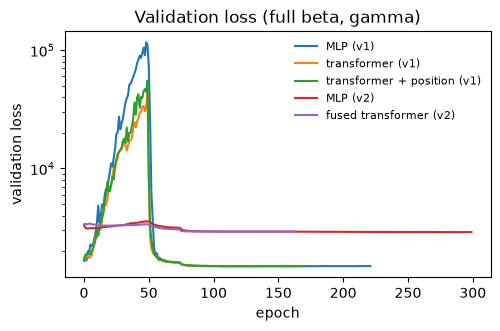

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
for name, h in histories.items():
    ax.plot(h["val_loss"], label=name)
ax.set(xlabel="epoch", ylabel="validation loss", yscale="log", title="Validation loss (full beta, gamma)")
ax.legend(frameon=False, fontsize=8)
plt.show()

Losses of `v1` and `v2` models are different objectives, so compare curves only within an objective.

## 3. Benchmark on held-out cells

- **FOSCTTM** and **Recall@10**: are a cell's RNA and ATAC embeddings close to each other?
- **label transfer** (RNA → ATAC, k-NN) and its macro-F1 in the worse direction;
- **ATAC → RNA**: median per-gene Pearson correlation of RNA predicted from accessibility alone;
- **fused kNN accuracy**: 5-fold cross-validated 15-NN cell-type accuracy on the embedding that uses
  both modalities (the fused transformer's posterior, or the precision-weighted MoE for the others).

In [7]:
labels = test["rna"].obs["cell_type"].astype(str).to_numpy()
observed = dense(test["rna"].X)
rows, fused_z = {}, {}
for name, model in models.items():
    z_r = encode_adata(model, test["rna"], modality="rna", device=device, latent="modality_mean")
    z_a = encode_adata(model, test["atac"], modality="atac", device=device, latent="modality_mean")
    m = evaluate_alignment(Z1=z_r, Z2=z_a, labels_source=labels, labels_target=labels, recall_ks=(10,))
    pred = cross_modal_predict(model, test["atac"], src_mod="atac", tgt_mod="rna", device=device)
    fz = encode_fused_adata_pair(model, {"rna": test["rna"], "atac": test["atac"]}, device=device,
                                 write_to_adatas=False)["mu"]
    fused_z[name] = fz
    folds = int(min(5, pd.Series(labels).value_counts().min())) if len(set(labels)) > 1 else 0
    acc = (cross_val_score(KNeighborsClassifier(15), fz, labels, cv=folds).mean() if folds >= 2 else np.nan)
    rows[name] = {"FOSCTTM ↓": m["foscttm_mean"], "Recall@10 ↑": m["recall_at_k"]["10"]["mean"],
                  "label transfer ↑": m["label_transfer_acc"], "macro-F1 (worse dir.) ↑": m["worst_direction_macro_f1"],
                  "ATAC→RNA median r ↑": float(np.nanmedian(pearson_corr_per_feature(observed, pred))),
                  "fused kNN acc ↑": acc, "train min": minutes[name]}
bench = pd.DataFrame(rows).T
bench.round(3)

,FOSCTTM ↓,Recall@10 ↑,label transfer ↑,macro-F1 (worse dir.) ↑,ATAC→RNA median r ↑,fused kNN acc ↑,train min
MLP (v1),0.044,0.358,0.877,0.687,0.266,0.876,8.161
transformer (v1),0.083,0.172,0.724,0.497,0.219,0.823,15.458
transformer + position (v1),0.073,0.153,0.753,0.511,0.205,0.830,278.042
MLP (v2),0.049,0.327,0.847,0.630,0.231,0.849,10.247
fused transformer (v2),0.050,0.311,0.847,0.616,0.243,0.840,15.981


This is a single seed on one dataset. Before concluding that one encoder is better, repeat the
comparison over a few seeds (differences between seeds can be as large as differences between models).

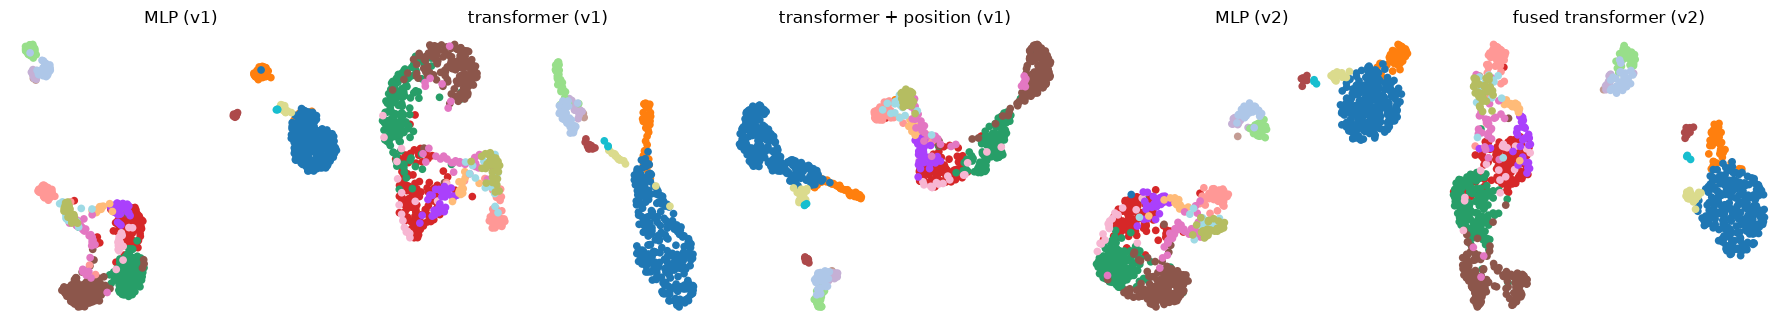

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(3.6 * len(models), 3.4))
for ax, (name, fz) in zip(np.atleast_1d(axes), fused_z.items()):
    a = ad.AnnData(fz.astype(np.float32),
                   obs=pd.DataFrame({"cell_type": pd.Categorical(labels)}, index=test["rna"].obs_names))
    sc.pp.neighbors(a, n_neighbors=30, use_rep="X")
    sc.tl.umap(a, random_state=0)
    sc.pl.umap(a, color="cell_type", ax=ax, show=False, legend_loc="none", title=name, frameon=False)
plt.tight_layout()
plt.show()

## 4. Inside the fused transformer

`fused_encode_with_meta_and_attn` runs the fused encoder and returns the attention matrices of every
layer (averaged over heads) together with a token map: which slice of the sequence belongs to which
modality and, for top-k tokenizers, which feature each token was in each cell.

In [9]:
fused = models["fused transformer (v2)"]
fused.eval()
n_cells = min(MAX_ATTENTION_CELLS, test["rna"].n_obs)
cells = np.random.default_rng(0).choice(test["rna"].n_obs, n_cells, replace=False)
X_rna, X_atac = dense(test["rna"].X[cells]), dense(test["atac"].X[cells])


def attention_batches(batch=256, model=None, limit=None):
    model = fused if model is None else model
    for s in range(0, n_cells if limit is None else min(limit, n_cells), batch):
        xb = {"rna": torch.as_tensor(X_rna[s:s + batch], dtype=torch.float32, device=device),
              "atac": torch.as_tensor(X_atac[s:s + batch], dtype=torch.float32, device=device)}
        _, _, tokmap, attn = fused_encode_with_meta_and_attn(model, xb, return_attn=True)
        yield s, tokmap, attn


_, tokmap0, attn0 = next(attention_batches(8))
print("token slices:", tokmap0.slices, "| global CLS:", tokmap0.has_global_cls,
      "| layers:", len(attn0), "| attention shape:", tuple(attn0[0].shape))

token slices: {'rna': (0, 128), 'atac': (128, 256)} | global CLS: False | layers: 2 | attention shape: (8, 256, 256)


### How much attention crosses modalities?

For each layer, the average attention a query token of one modality sends to key tokens of each
modality (rows sum to 1). Off-diagonal mass is cross-modal mixing.

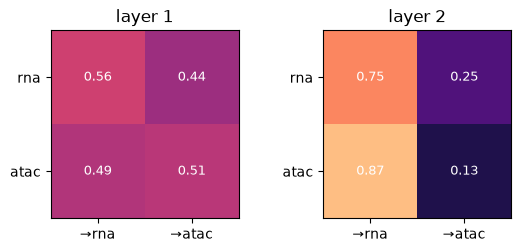

In [10]:
mods = list(tokmap0.slices)
mass = np.zeros((len(attn0), len(mods), len(mods)))
count = 0
for s, tokmap, attn in attention_batches():
    shift = 1 if tokmap.has_global_cls else 0
    for li, A in enumerate(attn):
        A = A.float().cpu().numpy()
        for i, qa in enumerate(mods):
            a0, a1 = [v + shift for v in tokmap.slices[qa]]
            for j, kb in enumerate(mods):
                b0, b1 = [v + shift for v in tokmap.slices[kb]]
                mass[li, i, j] += A[:, a0:a1, b0:b1].sum(-1).mean(-1).sum()
    count += A.shape[0]
mass /= count
fig, axes = plt.subplots(1, len(attn0), figsize=(2.8 * len(attn0), 2.6))
for li, ax in enumerate(np.atleast_1d(axes)):
    im = ax.imshow(mass[li], vmin=0, vmax=1, cmap="magma")
    for i in range(len(mods)):
        for j in range(len(mods)):
            ax.text(j, i, f"{mass[li, i, j]:.2f}", ha="center", va="center", color="w", fontsize=9)
    ax.set_xticks(range(len(mods)), [f"→{m}" for m in mods])
    ax.set_yticks(range(len(mods)), mods)
    ax.set_title(f"layer {li + 1}")
plt.tight_layout()
plt.show()

### One cell, every token

The full last-layer attention matrix of a single test cell: rows are query tokens, columns are key
tokens, gene tokens first and peak tokens after the white lines. Color is on a log scale, because a few
entries dominate. The most-attended tokens (largest column sums) are labeled.

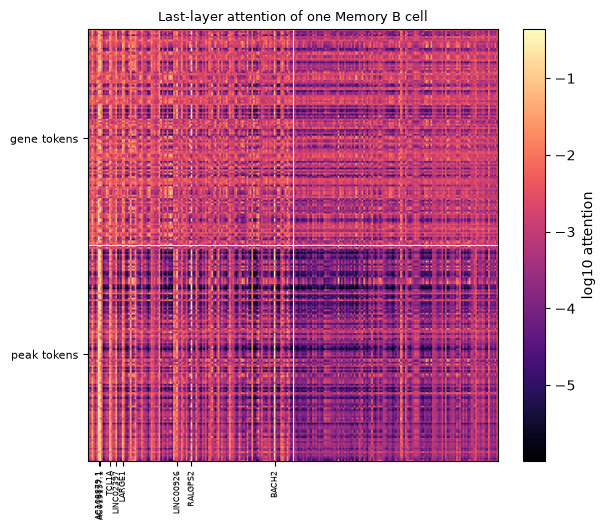

In [11]:
_, tokmap1, attn1 = next(attention_batches(1))
shift1 = 1 if tokmap1.has_global_cls else 0
A1 = attn1[-1][0].float().cpu().numpy()
names1 = ([test["rna"].var_names[i] for i in tokmap1.meta["rna"]["topk_idx"][0].cpu().numpy()]
          + [test["atac"].var_names[i] for i in tokmap1.meta["atac"]["topk_idx"][0].cpu().numpy()])
names1 = (["CLS"] if shift1 else []) + names1
fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(np.log10(A1 + 1e-6), cmap="magma", aspect="auto")
cut = tokmap1.slices["rna"][1] + shift1
ax.axhline(cut - 0.5, c="w", lw=0.8)
ax.axvline(cut - 0.5, c="w", lw=0.8)
top_cols = np.argsort(-A1.sum(0))[:8]
ax.set_xticks(top_cols, [names1[j][:18] for j in top_cols], rotation=90, fontsize=6)
ax.set_yticks([cut / 2, cut + (A1.shape[0] - cut) / 2], ["gene tokens", "peak tokens"], fontsize=8)
plt.colorbar(im, ax=ax, label="log10 attention")
ax.set_title(f"Last-layer attention of one {labels[cells[0]]} cell", fontsize=9)
plt.tight_layout()
plt.show()

### How sharp is attention?

For every query token, the entropy of its attention distribution divided by the entropy of uniform
attention over all tokens (1 = spread evenly, near 0 = focused on one token). Sharp attention in a layer
means that layer routes information between specific tokens; near-uniform attention means it mostly
averages.

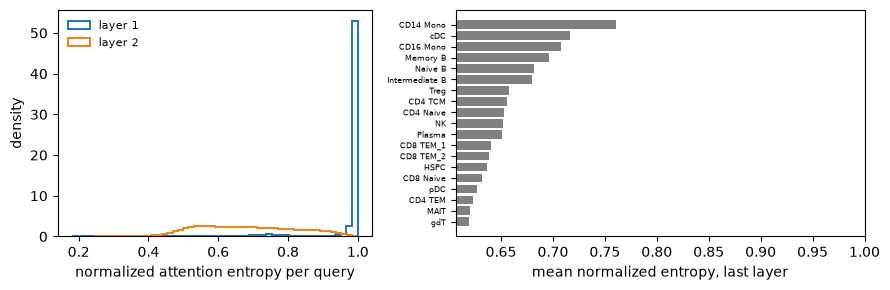

In [12]:
ent = {li: [] for li in range(len(attn0))}
ent_cell = []
for s_, tokmap, attn in attention_batches():
    for li, A in enumerate(attn):
        A = A.float().cpu().numpy()
        h = -(A * np.log(A + 1e-12)).sum(-1) / np.log(A.shape[-1])          # (cells, queries)
        ent[li].append(h.ravel())
        if li == len(attn) - 1:
            ent_cell.append(h.mean(1))
ent_cell = np.concatenate(ent_cell)
fig, axes = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={"width_ratios": [1, 1.3]})
for li, h in ent.items():
    axes[0].hist(np.concatenate(h), bins=50, histtype="step", density=True, lw=1.4, label=f"layer {li + 1}")
axes[0].set(xlabel="normalized attention entropy per query", ylabel="density")
axes[0].legend(frameon=False, fontsize=8)
per_type = pd.Series(ent_cell, index=labels[cells[:len(ent_cell)]]).groupby(level=0).mean().sort_values()
axes[1].barh(per_type.index, per_type.values, color="0.5")
axes[1].set(xlabel="mean normalized entropy, last layer", xlim=(per_type.min() * 0.98, 1.0))
axes[1].tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

### Which tokens does the fused embedding depend on? Attention rollout

The fused posterior is computed from the mean of the last layer's token states. **Attention rollout**
(Abnar & Zuidema, 2020) traces that back through the layers: each layer's attention is mixed with the
identity (for the residual connection), row-normalized, and the layers are multiplied, which gives how
much every input token contributes to every output token. Averaging over output tokens gives each input
token's share of the pooled embedding. Rollout is an approximation (it ignores the feed-forward blocks
and treats heads as averaged), so read it as a ranking.

For each cell type, genes are scored by their mean rollout share over the type's cells. The heatmap
shows the top genes of each type: "attention markers".

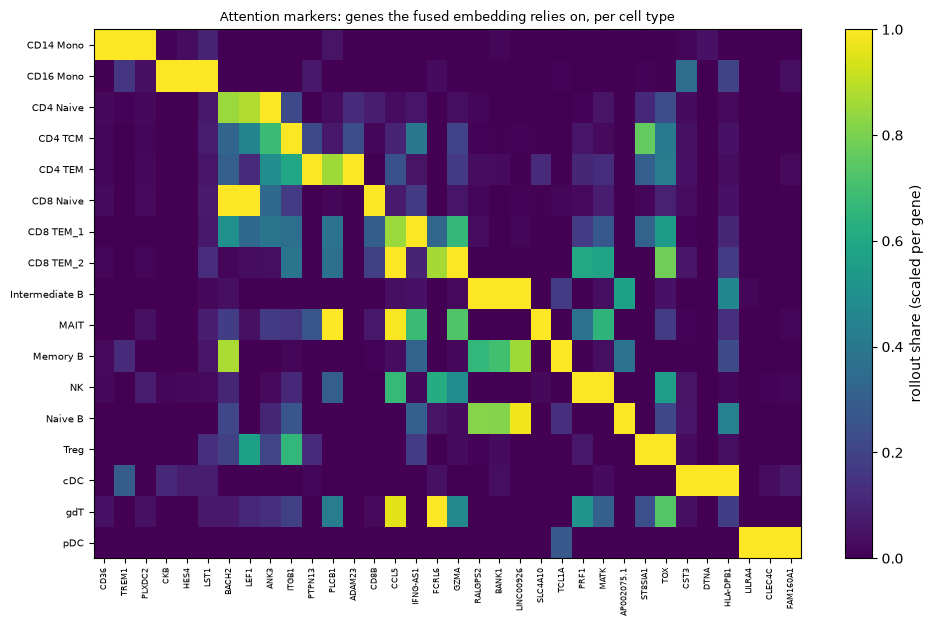

In [13]:
n_genes = test["rna"].var_names.size
cell_types_t = pd.Index(sorted(set(labels[cells])))
imp_sum = np.zeros((len(cell_types_t), n_genes))
present_n = np.zeros((len(cell_types_t), n_genes))
type_n = np.zeros(len(cell_types_t))
cross_share = []
for s_, tokmap, attn in attention_batches():
    shift = 1 if tokmap.has_global_cls else 0
    R = None
    for A in attn:
        A = A.float().cpu().numpy()
        A_hat = 0.5 * A + 0.5 * np.eye(A.shape[-1])[None]
        A_hat /= A_hat.sum(-1, keepdims=True)
        R = A_hat if R is None else A_hat @ R
    share = R.mean(1)                                                     # (cells, tokens): share of pooled output
    a0, a1 = [v + shift for v in tokmap.slices["rna"]]
    b0, b1 = [v + shift for v in tokmap.slices["atac"]]
    gi = tokmap.meta["rna"]["topk_idx"].cpu().numpy()
    t_idx = cell_types_t.get_indexer(labels[cells[s_:s_ + len(gi)]])
    for c in range(len(gi)):
        imp_sum[t_idx[c], gi[c]] += share[c, a0:a1]
        present_n[t_idx[c], gi[c]] += 1
        type_n[t_idx[c]] += 1
    A_last = attn[-1].float().cpu().numpy()
    cross_share.append(np.c_[A_last[:, a0:a1, b0:b1].sum(-1).mean(-1), A_last[:, b0:b1, a0:a1].sum(-1).mean(-1)])
cross_share = np.concatenate(cross_share)
rollout = pd.DataFrame(imp_sum / np.maximum(type_n[:, None], 1), index=cell_types_t, columns=test["rna"].var_names)
token_freq = pd.DataFrame(present_n / np.maximum(type_n[:, None], 1), index=cell_types_t, columns=test["rna"].var_names)
when_present = pd.DataFrame(np.where(present_n > 0, imp_sum / np.maximum(present_n, 1), np.nan),
                            index=cell_types_t, columns=test["rna"].var_names)

show_types = [t for t in cell_types_t if type_n[cell_types_t.get_loc(t)] >= 10]
top_genes_attn = list(dict.fromkeys(g for t in show_types for g in rollout.loc[t].nlargest(3).index))
M = rollout.loc[show_types, top_genes_attn]
M = M.div(M.max(axis=0) + 1e-12, axis=1)
fig, ax = plt.subplots(figsize=(0.22 * len(top_genes_attn) + 2.5, 0.28 * len(show_types) + 1.6))
im = ax.imshow(M.to_numpy(), cmap="viridis", aspect="auto")
ax.set_xticks(range(len(top_genes_attn)), top_genes_attn, rotation=90, fontsize=6)
ax.set_yticks(range(len(show_types)), show_types, fontsize=7)
plt.colorbar(im, ax=ax, label="rollout share (scaled per gene)")
ax.set_title("Attention markers: genes the fused embedding relies on, per cell type", fontsize=9)
plt.tight_layout()
plt.show()

**Does attention add anything to being a token?** Tokens are a cell's most over-expressed genes, so a
cell type's marker genes become tokens in its cells whatever the transformer learns. The test compares
three gene scores for recovering each type's `N_DE_GENES` top differentially expressed genes (t-test on
the test cells, one type against the rest), as AUROC over genes that are tokens in that type:

- **token frequency**: fraction of the type's cells in which the gene is a token (no attention involved);
- **rollout share**: mean rollout share over the type's cells (attention plus frequency);
- **share when present**: mean rollout share over cells in which the gene is a token (attention only).

If "share when present" stays near 0.5 while token frequency is high, the model's attention adds little
cell-type information beyond what token selection already carries.

In [14]:
from sklearn.metrics import roc_auc_score

de_adata = ad.AnnData(dense(test["rna"].X[cells]).astype(np.float32), obs=pd.DataFrame(
    {"cell_type": pd.Categorical(labels[cells])}, index=test["rna"].obs_names[cells]), var=pd.DataFrame(index=test["rna"].var_names))
sc.tl.rank_genes_groups(de_adata, "cell_type", groups=show_types, method="t-test", n_genes=N_DE_GENES)
rows = {}
for t in show_types:
    de = set(de_adata.uns["rank_genes_groups"]["names"][t])
    ok = present_n[cell_types_t.get_loc(t)] > 0
    genes_t = test["rna"].var_names[ok]
    y = np.array([g in de for g in genes_t])
    if y.all() or not y.any():
        continue
    rows[t] = {"genes scored": int(ok.sum()),
               "token frequency": roc_auc_score(y, token_freq.loc[t, genes_t]),
               "rollout share": roc_auc_score(y, rollout.loc[t, genes_t]),
               "share when present": roc_auc_score(y, when_present.loc[t, genes_t])}
de_test = pd.DataFrame(rows).T
display(de_test.round(3))
print("mean AUROC:", de_test[["token frequency", "rollout share", "share when present"]].mean().round(3).to_dict())

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


,genes scored,token frequency,rollout share,share when present
CD14 Mono,1355.0,0.765,0.768,0.538
CD16 Mono,886.0,0.815,0.811,0.431
CD4 Naive,1137.0,0.933,0.952,0.632
CD4 TCM,1165.0,0.974,0.978,0.556
CD4 TEM,805.0,0.976,0.970,0.601
CD8 Naive,1157.0,0.950,0.971,0.654
CD8 TEM_1,819.0,0.954,0.958,0.618
CD8 TEM_2,704.0,0.988,0.981,0.685
Intermediate B,792.0,0.978,0.969,0.558
MAIT,543.0,0.976,0.949,0.613


mean AUROC: {'token frequency': 0.934, 'rollout share': 0.93, 'share when present': 0.595}


### Cross-modal attention by cell type

The share of last-layer attention that gene tokens send to peak tokens, and peak tokens to gene tokens,
per cell type. Cell types that lean more on the other modality are those where the fused encoder mixes
chromatin and expression most.

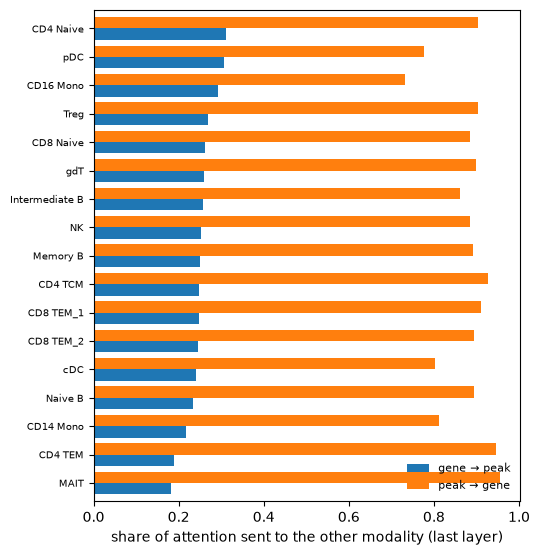

In [15]:
cs = pd.DataFrame(cross_share, columns=["gene → peak", "peak → gene"], index=labels[cells[:len(cross_share)]])
per_type_cs = cs.groupby(level=0).mean().loc[show_types].sort_values("gene → peak")
ax = per_type_cs.plot.barh(figsize=(5.5, 0.25 * len(per_type_cs) + 1.4), width=0.8)
ax.set(xlabel="share of attention sent to the other modality (last layer)", ylabel="")
ax.tick_params(axis="y", labelsize=7)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

### Collect the last layer's gene → peak attention

For the remaining analyses we keep, for every analyzed cell, the block of last-layer attention from
gene tokens (queries) to peak tokens (keys), the feature index behind every token, and a
**double-centered** copy of the block (each gene token's and each peak token's mean removed), which keeps
only pair-specific preferences.

In [16]:
def tss_table(var):
    need = ["chrom", "chromStart", "chromEnd", "strand"]
    if not set(need) <= set(var.columns):
        return None
    v = var[need].dropna()
    v = v[v["strand"].astype(str).isin(["+", "-"])]
    tss = np.where(v["strand"].astype(str) == "-", v["chromEnd"], v["chromStart"]).astype(np.int64)
    return pd.DataFrame({"chrom": v["chrom"].astype(str).to_numpy(), "tss": tss}, index=v.index)


tss = tss_table(rna.var)
pv = test["atac"].var
peak_chrom = pv["chrom"].astype(str).to_numpy() if "chrom" in pv else None
peak_mid = ((pv["chromStart"].astype(np.int64) + pv["chromEnd"].astype(np.int64)) // 2).to_numpy() \
    if {"chromStart", "chromEnd"} <= set(pv.columns) else None

As, Rs, GIs, PIs = [], [], [], []
for s, tokmap, attn in attention_batches():
    shift = 1 if tokmap.has_global_cls else 0
    a0, a1 = [v + shift for v in tokmap.slices["rna"]]
    b0, b1 = [v + shift for v in tokmap.slices["atac"]]
    A = attn[-1][:, a0:a1, b0:b1].float().cpu().numpy()                     # (cells, gene tokens, peak tokens)
    As.append(A)
    Rs.append(A - A.mean(2, keepdims=True) - A.mean(1, keepdims=True) + A.mean((1, 2), keepdims=True))
    GIs.append(tokmap.meta["rna"]["topk_idx"].cpu().numpy())                # feature index of each token
    PIs.append(tokmap.meta["atac"]["topk_idx"].cpu().numpy())
A, R, GI, PI = map(np.concatenate, (As, Rs, GIs, PIs))
del As, Rs
print("attention blocks:", A.shape)

attention blocks: (977, 128, 128)


### Attention sinks

Transformers often route much of their attention to a few "sink" tokens that act as a default target
rather than carrying pair-specific information. The table lists the peaks that receive the largest share
of all gene → peak attention in the last layer, and in how many analyzed cells each is a token. If a few
peaks take a large share, rankings of summed attention (such as the next table) are mostly lists of
genes paired with those peaks.

In [17]:
received = np.bincount(PI.ravel(), weights=A.sum(1).ravel(), minlength=test["atac"].n_vars)
present = np.bincount(PI.ravel(), minlength=test["atac"].n_vars)   # top-k tokens are distinct within a cell
sinks = pd.DataFrame({"share of gene→peak attention": received / received.sum(),
                      "cells where it is a token": present}, index=test["atac"].var_names)
sinks = sinks.sort_values("share of gene→peak attention", ascending=False)
print(f"top 1 peak: {sinks.iloc[0, 0]:.1%} of all gene→peak attention; top 10 peaks: {sinks.iloc[:10, 0].sum():.1%} "
      f"(a uniform split over tokens would give each peak about {1 / PI.shape[1]:.1%} within a cell)")
sinks.head(10).round(4)

top 1 peak: 1.0% of all gene→peak attention; top 10 peaks: 7.1% (a uniform split over tokens would give each peak about 0.8% within a cell)


,share of gene→peak attention,cells where it is a token
peaks,,
chr9:76575869-76578256,0.0102,83
chr7:74061683-74063106,0.0095,96
chr2:100653262-100654402,0.0090,73
chr4:71186279-71188343,0.0080,93
chr12:666580-669839,0.0079,80
chr18:79912524-79916050,0.0060,76
chr2:8090639-8091585,0.0058,77
chr5:68330941-68332991,0.0053,84
chr15:99434865-99439259,0.0050,78


### Gene → peak pairs

`top_cross_modal_feature_pairs_from_attn` sums, over cells, the raw attention from gene tokens to peak
tokens for each cell's strongest pairs. It is shown first as the built-in summary; it is dominated by
sinks and by features that are tokens in many cells.

In [18]:
_, tokmap_b, attn_b = next(attention_batches(512))
pairs = top_cross_modal_feature_pairs_from_attn(
    attn_b, tokmap_b, mod_a="rna", mod_b="atac",
    var_names_by_mod={"rna": test["rna"].var_names, "atac": test["atac"].var_names},
    tokenizer_mode_by_mod={"rna": "topk_channels", "atac": "topk_channels"},
    layer=-1, top_pairs_per_cell=50, top_n=15)
pd.DataFrame(pairs, columns=["gene", "peak", "summed_attention"]).round(3)

,gene,peak,summed_attention
0,IL32,chr2:100653262-100654402,4.204
1,BCL2,chr2:100653262-100654402,4.091
2,LRRK1,chr2:8090639-8091585,3.114
3,CD247,chr2:100653262-100654402,2.829
4,SLC43A2,chr2:8090639-8091585,2.827
5,CAMK4,chr2:100653262-100654402,2.651
6,PRR36,chr7:74061683-74063106,2.530
7,GK,chr2:8090639-8091585,2.510
8,CHST15,chr2:8090639-8091585,2.453
9,EFCAB6-AS1,chr7:74061683-74063106,2.439


A pair-specific ranking uses the centered attention instead: in every cell, the `TOP_PAIRS_PER_CELL`
pairs with the largest centered attention are counted, and each pair's count is divided by the number of
cells in which both of its features are tokens (pairs co-present in fewer than `MIN_COOCCURRENCE` cells
are dropped). A high rate means the model singles out that gene–peak combination whenever it can.

In [19]:
def annotate_pairs(df):
    if tss is None or peak_chrom is None:
        return df
    pidx = test["atac"].var_names.get_indexer(df["peak"])
    g = tss.reindex(df["gene"])
    same = g["chrom"].to_numpy() == peak_chrom[pidx]
    df["same_chromosome"] = same
    df["distance_to_tss_kb"] = np.where(same, np.abs(peak_mid[pidx] - g["tss"].to_numpy()) / 1e3, np.nan)
    return df


n_c, n_g, n_p = R.shape
k = min(TOP_PAIRS_PER_CELL, n_g * n_p)
top = np.argpartition(-R.reshape(n_c, -1), k - 1, axis=1)[:, :k]
g_feat = np.take_along_axis(GI, top // n_p, axis=1)
p_feat = np.take_along_axis(PI, top % n_p, axis=1)
n_peak_features = test["atac"].n_vars
counts = pd.Series((g_feat.astype(np.int64) * n_peak_features + p_feat).ravel()).value_counts()
cand = counts.index[:2000].to_numpy()
cg, cp = cand // n_peak_features, cand % n_peak_features
gene_present = np.zeros((n_c, test["rna"].n_vars), dtype=bool)
gene_present[np.arange(n_c)[:, None], GI] = True
peak_present = np.zeros((n_c, n_peak_features), dtype=bool)
peak_present[np.arange(n_c)[:, None], PI] = True
co = (gene_present[:, cg] & peak_present[:, cp]).sum(0)
ranked = pd.DataFrame({"gene": test["rna"].var_names[cg], "peak": test["atac"].var_names[cp],
                       "cells in top pairs": counts.loc[cand].to_numpy(), "cells co-present": co})
ranked = ranked[ranked["cells co-present"] >= MIN_COOCCURRENCE]
if ranked.empty:
    print(f"No pair is co-present in at least {MIN_COOCCURRENCE} analyzed cells; lower MIN_COOCCURRENCE or "
          "raise MAX_ATTENTION_CELLS.")
ranked["rate"] = ranked["cells in top pairs"] / ranked["cells co-present"]
annotate_pairs(ranked.sort_values(["rate", "cells in top pairs"], ascending=False).head(25).reset_index(drop=True)).round(3)

,gene,peak,cells in top pairs,cells co-present,rate,same_chromosome,distance_to_tss_kb
0,DENND1A,chr2:100653262-100654402,20,22,0.909,False,NaN
1,TFDP2,chr9:76575869-76578256,18,21,0.857,False,NaN
2,SLC43A2,chr2:8090639-8091585,26,31,0.839,False,NaN
3,CAMK2D,chr2:100653262-100654402,24,29,0.828,False,NaN
4,IL32,chr2:100653262-100654402,46,56,0.821,False,NaN
5,PRKN,chr2:100653262-100654402,23,28,0.821,False,NaN
6,CD247,chr2:100653262-100654402,40,49,0.816,False,NaN
7,GK,chr2:8090639-8091585,30,37,0.811,False,NaN
8,C9orf72,chr2:100653262-100654402,17,21,0.810,False,NaN
9,SAMD4A,chr2:8090639-8091585,16,20,0.800,False,NaN


### Do gene tokens attend more to their cis peaks?

A (gene, peak) pair is **cis** if the peak lies on the gene's chromosome within `CIS_WINDOW_BP` of its
TSS. A naive test ("are cis pairs over-represented among the highest attention weights?") is
confounded by sinks and by genes that send most of their attention to ATAC; on the synthetic stand-in
data used for our automated tests, which has no gene-peak structure at all, the naive version reported a
spurious 2-3x enrichment. The test therefore uses the centered attention: for every gene token with at
least one cis and one non-cis peak token, the **AUC** with which its centered attention separates cis
from non-cis peaks, averaged over gene tokens (0.5 = no preference).

The same gene–peak pairs recur in many cells, so cells are not independent samples and a bootstrap over
cells would be too optimistic. Instead the statistic is calibrated with a **permutation null**: peak
coordinates are shuffled across peaks (`N_PERMUTATIONS` times), which keeps the attention exactly as it
is but breaks its relation to genomic position. Both one-sided p-values are reported; the question asked
in advance is whether cis peaks get *more* attention.

eligible gene tokens: 4,295 in 977 cells
mean within-gene AUC (cis vs non-cis peaks): 0.478; permutation null 0.498 ± 0.014 (200 permutations)
p (cis gets more attention) = 0.910; p (cis gets less attention) = 0.095


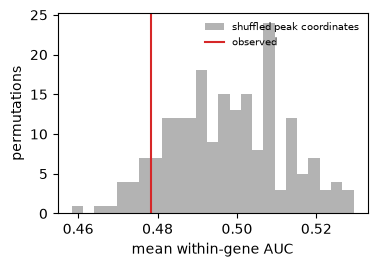

In [20]:
def mean_cis_auc(R, gi, pi, chrom_of_peak, mid_of_peak):
    """Mean within-gene AUC (cis vs non-cis peak tokens) of centered attention R (cells, genes, peaks)."""
    cis = ((g_chrom[gi][:, :, None] == chrom_of_peak[pi][:, None, :]) &
           (np.abs(g_tss[gi][:, :, None] - mid_of_peak[pi][:, None, :]) <= CIS_WINDOW_BP) &
           gene_ok[gi][:, :, None])
    n1 = cis.sum(2)
    n0 = cis.shape[2] - n1
    ok = (n1 > 0) & (n0 > 0)
    ranks = R.argsort(2).argsort(2) + 1.0                                  # within-row ranks (ties negligible)
    u = (ranks * cis).sum(2) - n1 * (n1 + 1) / 2
    auc = np.where(ok, u / np.maximum(n1 * n0, 1), np.nan)
    return np.nanmean(auc) if ok.any() else np.nan, int(ok.sum())


if tss is None or peak_chrom is None:
    print("Gene or peak coordinates are missing; skipping the cis test.")
else:
    gene_ok = test["rna"].var_names.isin(tss.index)
    g_chrom = np.full(test["rna"].n_vars, "", dtype=object)
    g_tss = np.zeros(test["rna"].n_vars, dtype=np.int64)
    g_chrom[gene_ok] = tss.loc[test["rna"].var_names[gene_ok], "chrom"].to_numpy()
    g_tss[gene_ok] = tss.loc[test["rna"].var_names[gene_ok], "tss"].to_numpy()
    observed_auc, n_rows = mean_cis_auc(R, GI, PI, peak_chrom, peak_mid)
    rng = np.random.default_rng(0)
    null_auc = []
    for _ in range(N_PERMUTATIONS):
        perm = rng.permutation(len(peak_chrom))
        null_auc.append(mean_cis_auc(R, GI, PI, peak_chrom[perm], peak_mid[perm])[0])
    null_auc = np.asarray(null_auc)
    null_auc = null_auc[np.isfinite(null_auc)]
    if not np.isfinite(observed_auc):
        print("No gene token had both cis and non-cis peak tokens; widen CIS_WINDOW_BP or raise the token counts.")
    else:
        p_more = (1 + (null_auc >= observed_auc).sum()) / (1 + len(null_auc))
        p_less = (1 + (null_auc <= observed_auc).sum()) / (1 + len(null_auc))
        print(f"eligible gene tokens: {n_rows:,} in {len(R):,} cells")
        print(f"mean within-gene AUC (cis vs non-cis peaks): {observed_auc:.3f}; permutation null "
              f"{null_auc.mean():.3f} ± {null_auc.std():.3f} ({len(null_auc)} permutations)")
        print(f"p (cis gets more attention) = {p_more:.3f}; p (cis gets less attention) = {p_less:.3f}")
        z_trained = (observed_auc - null_auc.mean()) / null_auc.std()
        fig, ax = plt.subplots(figsize=(4, 2.6))
        ax.hist(null_auc, bins=25, color="0.7", label="shuffled peak coordinates")
        ax.axvline(observed_auc, c="C3", label="observed")
        ax.set(xlabel="mean within-gene AUC", ylabel="permutations")
        ax.legend(frameon=False, fontsize=7)
        plt.show()

**A reference for how extreme "no knowledge" looks.** The permutation test is calibrated, but a single
model can still land a couple of standard deviations from the null by chance. The same statistic is
computed for `N_UNTRAINED_CONTROLS` untrained copies of the fused model (random weights, so their
attention cannot know anything about genomic position). When we ran 20 such untrained models on
synthetic data, their z-scores ranged from about -2.2 to +2.7, with 1 of 20 one-sided p-values at or
below 0.05, as expected for a calibrated test. Only a trained-model z well outside the controls' range,
reproduced across training seeds, is worth interpreting.

In [21]:
def cis_z(R_, GI_, PI_, n_perm, seed):
    obs, _ = mean_cis_auc(R_, GI_, PI_, peak_chrom, peak_mid)
    rng_ = np.random.default_rng(seed)
    null = np.array([mean_cis_auc(R_, GI_, PI_, peak_chrom[pp], peak_mid[pp])[0]
                     for pp in (rng_.permutation(len(peak_chrom)) for _ in range(n_perm))])
    null = null[np.isfinite(null)]
    return (obs - null.mean()) / null.std() if np.isfinite(obs) and len(null) > 1 else np.nan


if tss is not None and peak_chrom is not None and N_UNTRAINED_CONTROLS > 0 and "z_trained" in globals():
    cfg_f, kw_f = specs["fused transformer (v2)"]
    control = []
    for seed in range(N_UNTRAINED_CONTROLS):
        set_seed(1000 + seed)
        untrained = UniVIMultiModalVAE(cfg_f, normalize_v1_terms=True, **kw_f).to(device).eval()
        Rc, GIc, PIc = [], [], []
        for s, tokmap, attn in attention_batches(model=untrained, limit=500):
            shift = 1 if tokmap.has_global_cls else 0
            a0, a1 = [v + shift for v in tokmap.slices["rna"]]
            b0, b1 = [v + shift for v in tokmap.slices["atac"]]
            Ac = attn[-1][:, a0:a1, b0:b1].float().cpu().numpy()
            Rc.append(Ac - Ac.mean(2, keepdims=True) - Ac.mean(1, keepdims=True) + Ac.mean((1, 2), keepdims=True))
            GIc.append(tokmap.meta["rna"]["topk_idx"].cpu().numpy())
            PIc.append(tokmap.meta["atac"]["topk_idx"].cpu().numpy())
        control.append(cis_z(np.concatenate(Rc), np.concatenate(GIc), np.concatenate(PIc), 50, seed))
    print(f"trained fused model: z = {z_trained:+.2f}; untrained controls: "
          + ", ".join(f"{z:+.2f}" for z in control))

trained fused model: z = -1.34; untrained controls: -0.05, +0.10, -0.62, +0.63, +0.38


An observed value inside the permutation distribution and inside the range of the untrained controls
means the last layer shows no preference for cis peaks at this window. A clearly larger value would
suggest the fused encoder links genes to nearby regulatory regions, and a clearly smaller one that it
systematically attends *away* from them; either is worth checking across seeds and against the earlier
layer (`attn[0]` above) before interpreting it.

## 5. Saving and restoring a transformer model

`save_reference` writes the configuration (including the tokenizer options) and the weights;
`load_reference` rebuilds the model. The check confirms that the restored model reproduces the fused
embedding exactly. (For the position model, call `attach_peak_coordinates` again after loading: peak
coordinates are data and are not stored with the weights.)

In [22]:
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
save_reference(out_dir / "fused_transformer_reference", fused)
loaded = load_reference(out_dir / "fused_transformer_reference")
restored = (loaded[0] if isinstance(loaded, tuple) else getattr(loaded, "model", loaded)).to(device).eval()
same = np.allclose(encode_fused_adata_pair(restored, {"rna": test["rna"], "atac": test["atac"]}, device=device,
                                           write_to_adatas=False)["mu"], fused_z["fused transformer (v2)"], atol=1e-5)
print("restored model reproduces the fused embedding:", same)

restored model reproduces the fused embedding: True


## Notes and limitations

- **Objective vs. architecture.** Compare "fused transformer (v2)" with "MLP (v2)", and "transformer
  (v1)" with "MLP (v1)"; comparing across objectives mixes two changes.
- **Tokens drop information.** Each cell contributes only its top `N_TOKENS_*` features to a transformer
  encoder (128 of 20,000 peaks is 0.6%); the MLP sees every feature. This is the most likely reason a
  transformer trails the MLP here, and the first setting to vary. Larger token counts cost memory
  quadratically in the fused model.
- **Fused encoders.** With UniVI 1.1 and weight decay, a fused model's per-modality encoders could collapse
  (Section 2); use UniVI ≥ 1.2.0, and keep the spread check.
- **Saving.** `save_reference` / `load_reference` round-trip transformer models, including tokenizer
  options (Section 5); attach peak coordinates again after loading a position model.
- **Genomic coordinates.** Compare "transformer + position (v1)" with "transformer (v1)" to see what
  knowing where a peak lies adds. (In UniVI 1.1 the coordinate embedding ignored the position; fixed in
  1.2.0.)